In [ ]:
pip install gurobipy

In [ ]:
pip install cartopy

In [ ]:
pip install adjustText

NFL EXPANSION SITE SELECTION - SENSITIVITY ANALYSIS

✓ Using cities file: /content/drive/MyDrive/cities.csv
✓ Loaded 539 rows
✓ 174 cities with valid coordinates
✓ Population filters (φ): 5 columns
✓ Economic filters (θ): 5 columns
✓ Loaded 0 separation constraints

RUNNING SENSITIVITY ANALYSIS

Testing 4 × 4 = 16 threshold combinations...
Pop Threshold   Econ Threshold  Candidates   Selected   Status         
----------------------------------------------------------------------
1               1               174          71         ok             
1               2               173          71         ok             
1               3               169          N/A        cover_impossible
1               4               149          N/A        cover_impossible
2               1               173          71         ok             
2               2               173          71         ok             
2               3               169          N/A        cover_impossible
2       

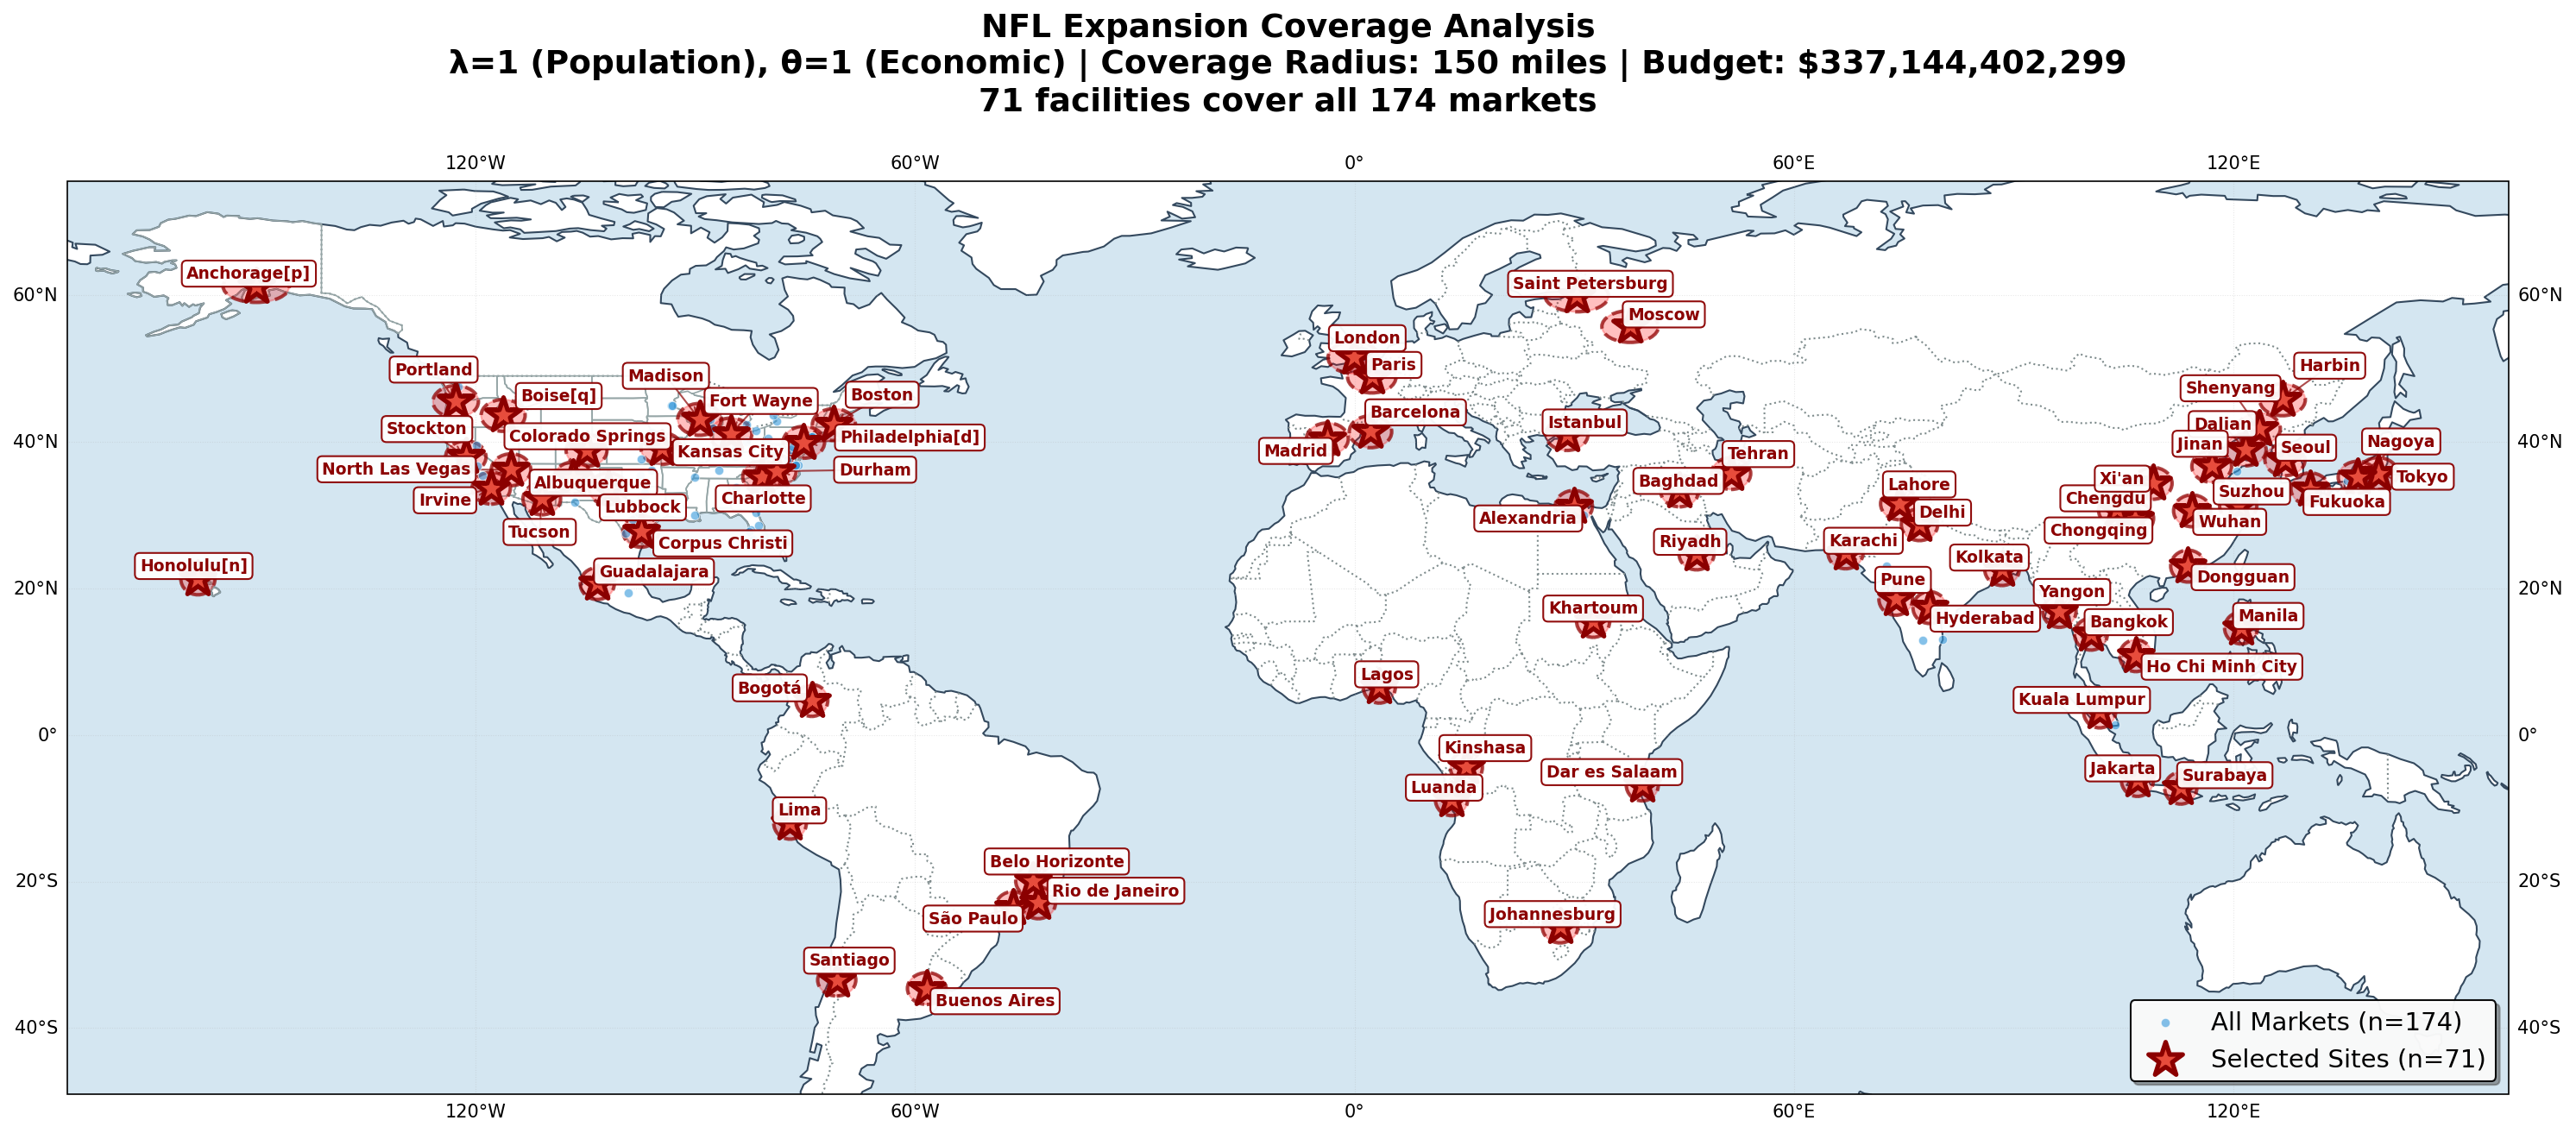

✓ Coverage map saved to: /content/drive/MyDrive/nfl_expansion_coverage_map.png

ANALYSIS COMPLETE

All outputs saved to: /content/drive/MyDrive
  • Sensitivity analysis: theta_lambda_sensitivity.csv
  • Solution data:        theta_lambda_best_solution.csv
  • Coverage map:         nfl_expansion_coverage_map.png


In [ ]:
#---------------------------------------------------------------------#
# NFL CONSTRAINED MINIMUM DOMINATING SET MODEL
# Gurobi Implementation for ISA 634 Final Project
# Authors: Jake Borders, Henry Fladung, Astin Lin, Dhritik Manchaiah,
#          James Sherman, Andrew Storer
#---------------------------------------------------------------------#
# Template-inspired structure from: 634_gurobi_intro.py
#---------------------------------------------------------------------#

import os, math, itertools
import pandas as pd, numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Try to import adjustText for better label positioning
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("Note: Install 'adjustText' for better label positioning: pip install adjustText")

# ==================== USER SETTINGS ====================
ROOT_DRIVE = "/content/drive/MyDrive"
TARGET = "cities.csv"

# Model / solver settings
R = 150                       # coverage radius (miles)
GLOBAL_BUDGET_FACTOR = 0.75   # global budget = factor * sum(cost of candidates)
TIME_LIMIT = 30               # seconds per solve (None -> no limit)
MIP_GAP = 1e-6

# Threshold grids (lambda = pop threshold; theta = econ threshold)
pop_thresholds = [1, 2, 3, 4]    # lambda sweep (φ thresholds)
theta_thresholds = [1, 2, 3, 4]  # theta sweep (θ thresholds)

# Output files
OUT_SENS_CSV = "theta_lambda_sensitivity.csv"
OUT_SOLUTION_CSV = "theta_lambda_best_solution.csv"
OUT_COVERAGE_MAP = "nfl_expansion_coverage_map.png"

# ==================== HELPER FUNCTIONS ====================
def find_file(root, name):
    """Recursively search for file in directory tree."""
    for p, dirs, files in os.walk(root):
        if name in files:
            return os.path.join(p, name)
    return None

def safe_clean_cols(df):
    """Clean DataFrame column names."""
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df.columns = (df.columns.str.strip()
                          .str.replace("\n","")
                          .str.replace("\t","")
                          .str.replace(" ", "_"))
    return df

def safe_coord(x):
    """Convert coordinate strings (e.g., '40.7128 N') to float degrees."""
    if pd.isna(x): return np.nan
    s = str(x).strip().upper().replace(",", "")
    try:
        if s.endswith("N"): return float(s[:-1])
        if s.endswith("S"): return -float(s[:-1])
        if s.endswith("E"): return float(s[:-1])
        if s.endswith("W"): return -float(s[:-1])
        return float(s)
    except:
        return np.nan

def parse_money(x):
    """Convert money strings (e.g., '$6,680,000,000') to float."""
    if pd.isna(x): return np.nan
    s = str(x).replace("$","").replace(",","").strip()
    try:
        return float(s)
    except:
        return np.nan

def haversine_miles(lat1, lon1, lat2, lon2):
    """Calculate great circle distance between two points in miles."""
    R_earth = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2)
    return 2 * R_earth * math.atan2(math.sqrt(a), math.sqrt(1-a))

# ==================== DATA LOADING ====================
print("="*70)
print("NFL EXPANSION SITE SELECTION - SENSITIVITY ANALYSIS")
print("="*70)

csv_path = find_file(ROOT_DRIVE, TARGET)
if csv_path is None:
    raise FileNotFoundError(f"{TARGET} not found under {ROOT_DRIVE}. Mount Drive and/or adjust ROOT_DRIVE.")

print(f"\n✓ Using cities file: {csv_path}")
raw = pd.read_csv(csv_path, dtype=str)
raw = safe_clean_cols(raw)
print(f"✓ Loaded {len(raw)} rows")

# Filter valid city rows
if "CityID" in raw.columns:
    raw = raw[raw["CityID"].astype(str).str.match(r"^\d+$", na=False)]

# Parse coordinates and budget
if "Latitude" not in raw.columns or "Longitude" not in raw.columns:
    raise KeyError("Latitude/Longitude columns required in CSV.")

raw["Latitude_num"]  = raw["Latitude"].apply(safe_coord)
raw["Longitude_num"] = raw["Longitude"].apply(safe_coord)
if "Budget" in raw.columns:
    raw["Budget_num"] = raw["Budget"].apply(parse_money)
else:
    raw["Budget_num"] = np.nan

df = raw.dropna(subset=["Latitude_num","Longitude_num"]).reset_index(drop=True)
print(f"✓ {len(df)} cities with valid coordinates")

# Identify phi and theta columns
phi_cols = [c for c in df.columns if c.lower().startswith("φ") or c.lower().startswith("phi")]
theta_cols = [c for c in df.columns if c.lower().startswith("θ") or c.lower().startswith("theta")]

if len(phi_cols) == 0 or len(theta_cols) == 0:
    print("⚠ Warning: couldn't auto-detect phi/theta columns")
print(f"✓ Population filters (φ): {len(phi_cols)} columns")
print(f"✓ Economic filters (θ): {len(theta_cols)} columns")

# Convert phi/theta to numeric
for c in phi_cols + theta_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# Extract key arrays
cost = df.get("Budget_num", pd.Series(np.ones(len(df)))).astype(float).values
lat = df["Latitude_num"].astype(float).values
lon = df["Longitude_num"].astype(float).values
index_series = pd.Series(df.index.astype(str), index=df.index)

names = df["CityName"].astype(str)
names = names.replace(["", " ", "nan", "NaN", "None"], np.nan)
names = names.fillna(index_series).values

ids = df["CityID"].astype(str)
ids = ids.replace(["", " ", "nan", "NaN", "None"], np.nan)
ids = ids.fillna(index_series).values
n = len(df)

# Load separation constraints if available
sep_path = os.path.join(os.path.dirname(csv_path), "separation.csv")
S_pairs = []
if os.path.exists(sep_path):
    sep = pd.read_csv(sep_path)
    if {"i","k"}.issubset(sep.columns):
        for _, r in sep.iterrows():
            a, b = str(r["i"]), str(r["k"])
            if a in ids: ia = int(np.where(ids==a)[0][0])
            else: ia = int(a)
            if b in ids: ib = int(np.where(ids==b)[0][0])
            else: ib = int(b)
            if 0 <= ia < n and 0 <= ib < n: S_pairs.append((ia, ib))
print(f"✓ Loaded {len(S_pairs)} separation constraints")

# ==================== OPTIMIZATION MODEL ====================
def build_adjacency(radius):
    """Build adjacency matrix based on distance threshold."""
    A = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            if math.isnan(lat[i]) or math.isnan(lon[i]) or math.isnan(lat[j]) or math.isnan(lon[j]):
                A[i,j] = 0
            else:
                A[i,j] = 1 if haversine_miles(lat[i], lon[i], lat[j], lon[j]) <= radius else 0
    return A

def solve_for_thresholds(pop_th, theta_th, radius, global_budget, time_limit=TIME_LIMIT):
    """Solve facility location model for given threshold parameters."""
    pop_sum = df[phi_cols].sum(axis=1).astype(int).values if len(phi_cols)>0 else np.zeros(n,dtype=int)
    theta_sum = df[theta_cols].sum(axis=1).astype(int).values if len(theta_cols)>0 else np.zeros(n,dtype=int)
    p_ok = (pop_sum >= pop_th).astype(int)
    v_ok = (theta_sum >= theta_th).astype(int)
    V3 = [i for i in range(n) if (p_ok[i]==1 and v_ok[i]==1)]

    result = {"pop_th":pop_th, "theta_th":theta_th, "num_candidates": len(V3)}
    if len(V3) == 0:
        result.update({"status":"no_candidates", "num_selected": None, "selected":[], "total_cost": None})
        return result

    A = build_adjacency(radius)

    if global_budget is None:
        global_budget = GLOBAL_BUDGET_FACTOR * sum(cost[i] for i in V3)

    # Check coverage feasibility
    for j in range(n):
        coverers = [i for i in V3 if A[i,j]==1]
        if len(coverers) == 0:
            result.update({"status":"cover_impossible", "num_selected": None, "selected": [], "total_cost": None})
            return result

    # Build Gurobi model
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    if time_limit: model.setParam("TimeLimit", int(time_limit))
    model.setParam("MIPGap", MIP_GAP)

    x = {i: model.addVar(vtype=GRB.BINARY, name=f"x_{i}") for i in V3}
    model.update()
    model.setObjective(gp.quicksum(x[i] for i in V3), GRB.MINIMIZE)

    # Coverage constraints
    for j in range(n):
        coverers = [i for i in V3 if A[i,j]==1]
        model.addConstr(gp.quicksum(x[i] for i in coverers) >= 1, name=f"cov_{j}")

    # Budget constraint
    model.addConstr(gp.quicksum(cost[i]*x[i] for i in V3) <= global_budget, name="Budget")

    # Separation constraints
    for (i,k) in S_pairs:
        if i in x and k in x:
            model.addConstr(x[i] + x[k] <= 1)

    model.optimize()
    status = model.Status
    if status in (GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL):
        selected = [i for i in V3 if x[i].X > 0.5]
        total_cost = sum(cost[i] for i in selected)
        return {"pop_th":pop_th, "theta_th":theta_th, "num_candidates": len(V3),
                "status":"ok", "num_selected": len(selected), "selected": selected, "total_cost": total_cost}
    else:
        return {"pop_th":pop_th, "theta_th":theta_th, "num_candidates": len(V3),
                "status":f"gurobi_status_{status}", "num_selected": None, "selected": [], "total_cost": None}

# ==================== SENSITIVITY SWEEP ====================
print("\n" + "="*70)
print("RUNNING SENSITIVITY ANALYSIS")
print("="*70)

records = []
print(f"\nTesting {len(pop_thresholds)} × {len(theta_thresholds)} = {len(pop_thresholds)*len(theta_thresholds)} threshold combinations...")
print(f"{'Pop Threshold':<15} {'Econ Threshold':<15} {'Candidates':<12} {'Selected':<10} {'Status':<15}")
print("-" * 70)

for pop_th, theta_th in itertools.product(pop_thresholds, theta_thresholds):
    res = solve_for_thresholds(pop_th=pop_th, theta_th=theta_th, radius=R, global_budget=None)
    sel_ids = ";".join(ids[i] for i in (res["selected"] if res.get("selected") else []))
    records.append({
        "pop_th": res["pop_th"],
        "theta_th": res["theta_th"],
        "num_candidates": res["num_candidates"],
        "status": res["status"],
        "num_selected": res["num_selected"],
        "total_cost": res["total_cost"],
        "selected_ids": sel_ids
    })
    num_sel_display = res.get('num_selected') if res.get('num_selected') is not None else 'N/A'
    print(f"{res['pop_th']:<15} {res['theta_th']:<15} {res['num_candidates']:<12} {str(num_sel_display):<10} {res['status']:<15}")

sens_df = pd.DataFrame(records)
sens_path = os.path.join(ROOT_DRIVE, OUT_SENS_CSV)
sens_df.to_csv(sens_path, index=False)
print(f"\n✓ Sensitivity results saved to: {sens_path}")

# ==================== VISUALIZATION ====================
ok_runs = sens_df[sens_df["status"]=="ok"]
if not ok_runs.empty:
    best = ok_runs.sort_values(["num_selected","total_cost"], ascending=[False, False]).iloc[0]

    print("\n" + "="*70)
    print("BEST SOLUTION FOUND")
    print("="*70)
    print(f"Population Threshold (λ): {best['pop_th']}")
    print(f"Economic Threshold (θ):   {best['theta_th']}")
    print(f"Candidate Cities:         {best['num_candidates']}")
    print(f"Selected Cities:          {best['num_selected']}")
    print(f"Total Cost:               ${best['total_cost']:,.0f}")

    final = solve_for_thresholds(best["pop_th"], best["theta_th"], R, global_budget=None, time_limit=TIME_LIMIT)
    sel = final["selected"]

    # Save solution CSV
    out = df.copy()
    out["in_V3"] = 0
    pop_sum = df[phi_cols].sum(axis=1).astype(int).values
    theta_sum = df[theta_cols].sum(axis=1).astype(int).values
    out.loc[(pop_sum >= best["pop_th"]) & (theta_sum >= best["theta_th"]), "in_V3"] = 1
    out["selected"] = 0
    out.loc[sel, "selected"] = 1

    sol_path = os.path.join(ROOT_DRIVE, OUT_SOLUTION_CSV)
    out.to_csv(sol_path, index=False)
    print(f"\n✓ Solution CSV saved to: {sol_path}")

    # ========== Coverage Visualization ==========
    print("\nGenerating coverage visualization...")
    A_final = build_adjacency(R)

    # Fix coordinate swap for map
    map_df = out[out['in_V3']==1].copy()
    temp_lat = pd.to_numeric(map_df['Longitude_num'], errors='coerce')
    temp_lon = pd.to_numeric(map_df['Latitude_num'], errors='coerce')
    map_df['Latitude_num'] = temp_lat
    map_df['Longitude_num'] = temp_lon
    map_df = map_df.dropna(subset=['Latitude_num', 'Longitude_num'])

    selected_map = map_df[map_df['selected']==1]

    # Create single large coverage map
    fig = plt.figure(figsize=(20, 14), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set map extent
    lat_min, lat_max = map_df['Latitude_num'].min(), map_df['Latitude_num'].max()
    lon_min, lon_max = map_df['Longitude_num'].min(), map_df['Longitude_num'].max()
    lat_pad = (lat_max - lat_min) * 0.15
    lon_pad = (lon_max - lon_min) * 0.15
    ax.set_extent([lon_min - lon_pad, lon_max + lon_pad,
                   lat_min - lat_pad, lat_max + lat_pad],
                  crs=ccrs.PlateCarree())

    # Map features with better contrast
    ax.add_feature(cfeature.LAND, facecolor='#ffffff', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='#34495e', zorder=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1, edgecolor='#7f8c8d', zorder=1)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='#95a5a6', linewidth=0.8, zorder=1)

    # Draw coverage circles FIRST (so they appear behind everything)
    print(f"Drawing {len(selected_map)} coverage circles...")
    for idx, row in selected_map.iterrows():
        # More accurate radius calculation accounting for latitude
        lat_rad = math.radians(row['Latitude_num'])
        radius_lat = R / 69.0
        radius_lon = R / (69.0 * math.cos(lat_rad)) if math.cos(lat_rad) != 0 else radius_lat

        # Draw filled circle with strong color
        from matplotlib.patches import Ellipse
        circle = Ellipse((row['Longitude_num'], row['Latitude_num']),
                        width=2*radius_lon, height=2*radius_lat,
                        color='red', alpha=0.25,
                        transform=ccrs.PlateCarree(), zorder=2)
        ax.add_patch(circle)

        # Draw bold circle outline
        circle_outline = Ellipse((row['Longitude_num'], row['Latitude_num']),
                                width=2*radius_lon, height=2*radius_lat,
                                color='darkred', alpha=0.7, fill=False, linewidth=2,
                                linestyle='--',
                                transform=ccrs.PlateCarree(), zorder=3)
        ax.add_patch(circle_outline)

    # Plot all markets (to show what's being covered)
    all_markets = out.dropna(subset=['Latitude_num', 'Longitude_num'])
    all_markets_lat = pd.to_numeric(all_markets['Longitude_num'], errors='coerce')
    all_markets_lon = pd.to_numeric(all_markets['Latitude_num'], errors='coerce')
    ax.scatter(all_markets_lon, all_markets_lat,
               color='#3498db', s=25, alpha=0.6, label='All Markets (n=174)',
               edgecolors='white', linewidths=0.5,
               transform=ccrs.PlateCarree(), zorder=4)

    # Plot selected cities on top with larger stars
    ax.scatter(selected_map['Longitude_num'], selected_map['Latitude_num'],
               color='#e74c3c', s=400, marker='*', alpha=1.0,
               edgecolors='darkred', linewidths=2.5,
               label=f'Selected Sites (n={len(selected_map)})',
               transform=ccrs.PlateCarree(), zorder=5)

    # Add city names ONLY for selected cities using adjustText
    texts = []
    for _, row in selected_map.iterrows():
        txt = ax.text(row['Longitude_num'], row['Latitude_num'],
                row['CityName'], fontsize=9, color='darkred',
                fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         alpha=0.95, edgecolor='darkred', linewidth=1),
                transform=ccrs.PlateCarree(), zorder=6)
        texts.append(txt)

    # Use adjustText to prevent overlaps
    if HAS_ADJUST_TEXT:
        print("Adjusting text positions to prevent overlap...")
        adjust_text(texts,
                   arrowprops=dict(arrowstyle='->', color='darkred', lw=1, alpha=0.7),
                   expand_points=(1.5, 1.5),
                   expand_text=(1.3, 1.3),
                   force_points=(0.5, 0.5),
                   force_text=(0.8, 0.8),
                   lim=500,
                   ax=ax)

    # Add informative title
    plt.title(f"NFL Expansion Coverage Analysis\n"
             f"λ={best['pop_th']} (Population), θ={best['theta_th']} (Economic) | "
             f"Coverage Radius: {R} miles | Budget: ${best['total_cost']:,.0f}\n"
             f"{len(selected_map)} facilities cover all {len(all_markets)} markets",
             fontsize=18, fontweight='bold', pad=25)

    # Enhanced legend
    ax.legend(loc='lower right', fontsize=14, framealpha=0.95,
             edgecolor='black', fancybox=True, shadow=True)

    # Add grid for reference
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3, linestyle=':', zorder=0)

    plt.tight_layout()

    coverage_path = os.path.join(ROOT_DRIVE, OUT_COVERAGE_MAP)
    plt.savefig(coverage_path, dpi=300, bbox_inches="tight", facecolor='white')
    plt.show()
    print(f"✓ Coverage map saved to: {coverage_path}")

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)
    print(f"\nAll outputs saved to: {ROOT_DRIVE}")
    print(f"  • Sensitivity analysis: {OUT_SENS_CSV}")
    print(f"  • Solution data:        {OUT_SOLUTION_CSV}")
    print(f"  • Coverage map:         {OUT_COVERAGE_MAP}")

else:
    print("\n⚠ No feasible solutions found. Check sensitivity CSV for details.")
    print(f"   Saved to: {sens_path}")